# 02 — Data Preprocessing & Feature Engineering
## FMD Outbreak Prediction — Sri Lanka (2017–2024)

**Objective:** This notebook documents the preprocessing steps used to create
the final model-ready dataset. The raw data sources (explored in Notebook 01)
were merged, cleaned, and enriched with new features.

### Key Steps:
1. **Temporal Alignment:** Aligning all data to a monthly resolution.
2. **Spatial Alignment:** Merging district-level data using PCODEs.
3. **Feature Engineering:**
   - Cyclical encoding of months (sin/cos)
   - Monsoon phases (one-hot encoding)
   - Weather lags (rain_lag1, rain_lag2, temp_lag1, etc.)
4. **Feature Selection:** Removing redundant or highly correlated features.

In [1]:
import pandas as pd
import numpy as np
import os

BASE_DIR = r'..'
PROC_DIR = os.path.join(BASE_DIR, 'data', 'processed')
DATA_FILE = os.path.join(PROC_DIR, 'FMD_model_ready_main refined_final_dataset.csv')

# Load the final processed dataset to review its structure
df = pd.read_csv(DATA_FILE)

print(f"Final Dataset Shape: {df.shape}")
print(f"Columns:\n{df.columns.tolist()}")

Final Dataset Shape: (2400, 26)
Columns:
['year', 'month_num', 'district', 'PCODE', 'sin_month', 'cos_month', 'monsoon_phase_First_Inter_Monsoon', 'monsoon_phase_SW_Monsoon', 'monsoon_phase_Second_Inter_Monsoon', 'monsoon_phase_NE_Monsoon', 'rainfall_mm', 'r3h', 'rfq', 'rain_lag1', 'rain_lag2', 'rfq_lag1', 'Outbreak status', 'lat', 'lon', 'humidity', 'wind_speed', 'temp_lag1', 'humidity_lag1', 'wind_lag1', 'buffalo_density', 'livestock_density']


---
## 1. Feature Engineering: Cyclical Time Features

Months are cyclical (December is next to January). If we just use `month_num`
(1 to 12), the model thinks 12 and 1 are far apart. We solve this using sine
and cosine transformations.

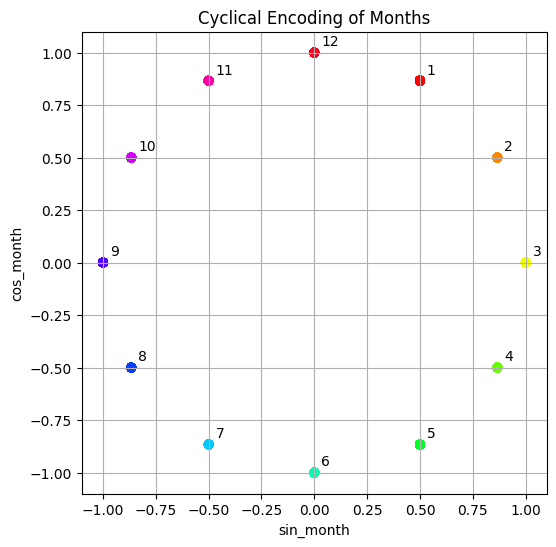

In [2]:
# Example of how cyclical features were created:
# df['sin_month'] = np.sin(2 * np.pi * df['month_num'] / 12)
# df['cos_month'] = np.cos(2 * np.pi * df['month_num'] / 12)

# Let's visualize the cyclical encoding present in our final dataset
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['sin_month'], df['cos_month'], c=df['month_num'], cmap='hsv')
for i in range(1, 13):
    sample = df[df['month_num'] == i].iloc[0]
    ax.annotate(str(i), (sample['sin_month'], sample['cos_month']),
                xytext=(5, 5), textcoords='offset points')
ax.set_title('Cyclical Encoding of Months')
ax.set_xlabel('sin_month')
ax.set_ylabel('cos_month')
ax.grid(True)
plt.show()

---
## 2. Feature Engineering: Monsoon Phases

Sri Lanka's climate is dominated by four monsoon phases. Outbreaks often
correlate with specific weather conditions. We one-hot encoded the monsoon
phases based on the month.

- **First Inter-Monsoon:** March – April
- **SW Monsoon:** May – September
- **Second Inter-Monsoon:** October – November
- **NE Monsoon:** December – February

In [3]:
monsoon_cols = [
    'monsoon_phase_First_Inter_Monsoon',
    'monsoon_phase_SW_Monsoon',
    'monsoon_phase_Second_Inter_Monsoon',
    'monsoon_phase_NE_Monsoon'
]

print("Monsoon Phase Encoding Example:")
print(df[['month_num'] + monsoon_cols].drop_duplicates().sort_values('month_num').head(12))

Monsoon Phase Encoding Example:
    month_num  monsoon_phase_First_Inter_Monsoon  monsoon_phase_SW_Monsoon  \
0           1                                  0                         0   
1           2                                  0                         0   
2           3                                  1                         0   
3           4                                  1                         0   
4           5                                  0                         1   
5           6                                  0                         1   
6           7                                  0                         1   
7           8                                  0                         1   
8           9                                  0                         1   
9          10                                  0                         0   
10         11                                  0                         0   
11         12                   

---
## 3. Feature Engineering: Lag Features

The incubation period and spread of FMD mean that weather conditions from
previous months might be more predictive than current conditions. We created
lag features (e.g., `rain_lag1` = rainfall from 1 month ago).

In [4]:
lag_cols = [c for c in df.columns if 'lag' in c]
print(f"Created Lag Features: {lag_cols}")

# Example of how lag features correlate with current values
print("\nCorrelation between current rainfall and lags:")
print(df[['rainfall_mm', 'rain_lag1', 'rain_lag2']].corr())

Created Lag Features: ['rain_lag1', 'rain_lag2', 'rfq_lag1', 'temp_lag1', 'humidity_lag1', 'wind_lag1']

Correlation between current rainfall and lags:
             rainfall_mm  rain_lag1  rain_lag2
rainfall_mm     1.000000   0.462054   0.147945
rain_lag1       0.462054   1.000000   0.476169
rain_lag2       0.147945   0.476169   1.000000


---
## 4. Spatial Integration & Refinement

We merged livestock density (buffalo, livestock) and location data (lat, lon)
using the district `PCODE`.

In the final refinement step, we dropped columns that were redundant or had
poor predictive value (e.g., `cattle_density` was highly correlated with
`buffalo_density` and `livestock_density`, so we kept the most relevant ones).

In [5]:
print("Final set of spatial/density features:")
print(df[['district', 'PCODE', 'lat', 'lon', 'buffalo_density', 'livestock_density']].head())

Final set of spatial/density features:
  district PCODE     lat      lon  buffalo_density  livestock_density
0  Colombo  LK11  6.9271  79.8612         5.445477          15.012142
1  Colombo  LK11  6.9271  79.8612         5.445477          15.012142
2  Colombo  LK11  6.9271  79.8612         5.445477          15.012142
3  Colombo  LK11  6.9271  79.8612         5.445477          15.012142
4  Colombo  LK11  6.9271  79.8612         5.445477          15.012142


---
## Summary of Preprocessing Pipeline

1. **DAPH Data:** Cleaned district names, mapped to PCODEs, expanded to a full
   25x12x8 panel (filling months with no outbreaks as 0).
2. **CHIRPS Data:** Aggregated dekadal `rfh`, `r3h`, `rfq` to monthly sums/maxs per PCODE.
3. **Weather Data:** Merged monthly temp, humidity, wind_speed per PCODE.
4. **GLW Data:** Extracted zonal mean density for buffalo and cattle using shapefiles.
5. **Feature Engineering:** Added cyclical time, monsoons, and lags.
6. **Refinement:** Dropped redundant features to arrive at the 26 final columns.

The final dataset is `FMD_model_ready_main refined_final_dataset.csv`.

**Next:** Notebook 03 will explore this final dataset to uncover patterns.